# Projeto CardioIA - Visão Computacional (Fase 4)
## Parte 1: Pré-processamento e Organização das Imagens
## Parte 2: Classificação de Imagens Médicas com CNN e Transfer Learning Otimizado

Importação das Bibliotecas

In [11]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
BASE_DIR = r"C:\Users\Fran\Nova pasta\fiap-fase4\dataset_estruturado"

Carregamento dos Datasets via TensorFlow API

In [13]:
# Resolução expandida para 256x256 para reter detalhes anatômicos sutis
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

print("🔄 Carregando subconjuntos de imagens direto do diretório estruturado...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Salva a lista de classes globalmente
class_names = train_ds.class_names
print(f"📌 Classes detectadas em disco: {class_names}\n")

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'validation'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False  # Mantido False para não desalinhá-lo com o relatório de métricas
)

🔄 Carregando subconjuntos de imagens direto do diretório estruturado...
Found 2620 files belonging to 3 classes.
📌 Classes detectadas em disco: ['Cardiomegalia', 'Infiltrado', 'Saudavel']

Found 561 files belonging to 3 classes.
Found 564 files belonging to 3 classes.


Ativação do Prefetching (Otimização de Memória)

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Inspeção Visual das Imagens

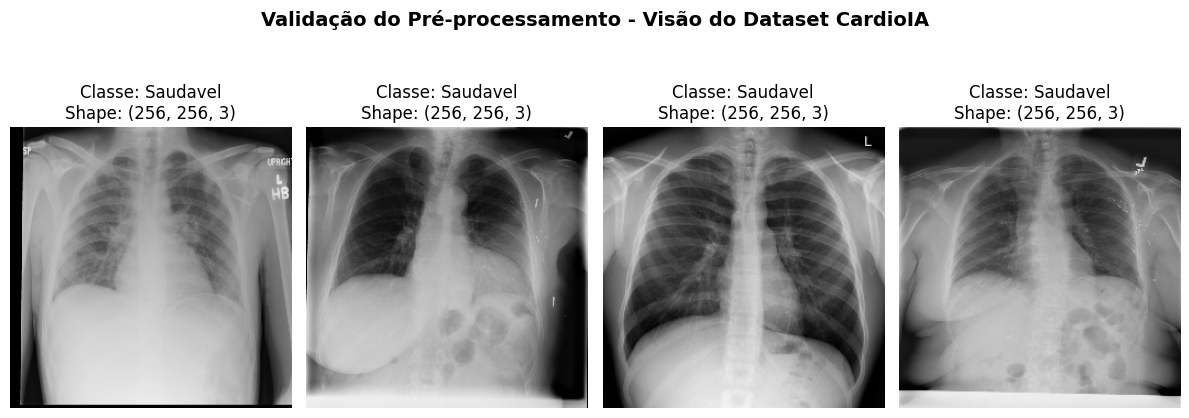

Valor de Pixel Máximo: 255.0 | Mínimo: 0.0


In [15]:
for images_batch, labels_batch in train_ds.take(1):
    plt.figure(figsize=(12, 5))
    for i in range(min(4, len(images_batch))):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images_batch[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels_batch[i])
        plt.title(f"Classe: {class_names[label_idx]}\nShape: {images_batch[i].shape}")
        plt.axis('off')

    plt.suptitle("Validação do Pré-processamento - Visão do Dataset CardioIA", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Valor de Pixel Máximo: {images_batch.numpy().max()} | Mínimo: {images_batch.numpy().min()}")

## PARTE 2 - Classificação de Imagens Médicas com CNN
### Abordagem 1: Arquitetura CNN Desenvolvida do Zero (Baseline)

In [ ]:
# Data Augmentation robusto adaptado para exames de radiologia
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15)  # Essencial para simular variações de opacidade
])

model_do_zero = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    
    # Bloco 1 - Filtros largos para formas gerais
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco 2 - Começando a fechar nos detalhes
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco 3 - Texturas intermediárias
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),

    # NOVO Bloco 4 - Filtros profundos para detalhes microscópicos de opacidade
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),
    
    # Classificação
    layers.Flatten(),
    layers.Dense(256), # Aumentado de 128 para 256 para segurar a complexidade
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model_do_zero.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_do_zero.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,169,603 (65.50 MB)

 Trainable params: 17,168,131 (65.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

Treinamento da CNN do Zero

In [17]:
print("⚖️ 1. Computando pesos automáticos para a CNN do Zero...")
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
train_labels_indices = np.argmax(train_labels, axis=1)
classes_finais = np.unique(train_labels_indices)

pesos_calculados = compute_class_weight(
    class_weight='balanced', 
    classes=classes_finais, 
    y=train_labels_indices
)
class_weight_dict = dict(zip(classes_finais, pesos_calculados))
print(f"Pesos aplicados: {class_weight_dict}")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("\n🏋️ 2. Treinando modelo básico do zero...")
history_zero = model_do_zero.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
print("✅ Treinamento da rede básica finalizado!")

⚖️ 1. Computando pesos automáticos para a CNN do Zero...
Pesos aplicados: {np.int64(0): np.float64(6.374695863746958), np.int64(1): np.float64(1.5707434052757794), np.int64(2): np.float64(0.45320878740702303)}

🏋️ 2. Treinando modelo básico do zero...
Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 282s 3s/step - accuracy: 0.3687 - loss: 1.4773 - precision_2: 0.3758 - recall_2: 0.3019 - val_accuracy: 0.0553 - val_loss: 1.6390 - val_precision_2: 0.0595 - val_recall_2: 0.0517
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.4145 - loss: 1.2607 - precision_2: 0.4441 - recall_2: 0.3378 - val_accuracy: 0.1301 - val_loss: 1.3736 - val_precision_2: 0.1285 - val_recall_2: 0.0410
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.4347 - loss: 1.1795 - precision_2: 0.4571 - recall_2: 0.3336 - val_accuracy: 0.0873 - val_loss: 1.6102 - val_precision_2: 0.0746 - val_recall_2: 0.0446
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.4473 - loss: 1.1460 - precision_

Métricas e Matriz de Confusão

18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 776ms/step


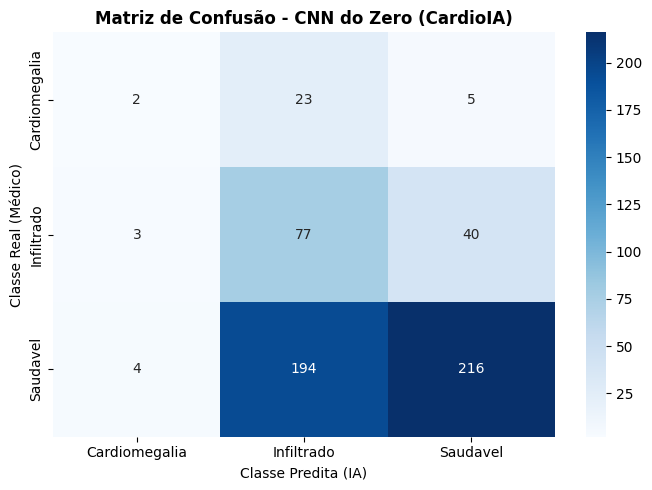


📋 --- RELATÓRIO DE MÉTRICAS (CNN DO ZERO) ---
               precision    recall  f1-score   support

Cardiomegalia       0.22      0.07      0.10        30
   Infiltrado       0.26      0.64      0.37       120
     Saudavel       0.83      0.52      0.64       414

     accuracy                           0.52       564
    macro avg       0.44      0.41      0.37       564
 weighted avg       0.68      0.52      0.55       564



In [18]:
predictions_zero = model_do_zero.predict(test_ds, verbose=1)
y_pred_zero = np.argmax(predictions_zero, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true, axis=1)

cm_zero = confusion_matrix(y_true_indices, y_pred_zero)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_zero, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CNN do Zero (CardioIA)', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n📋 --- RELATÓRIO DE MÉTRICAS (CNN DO ZERO) ---")
print(classification_report(y_true_indices, y_pred_zero, target_names=class_names))

### Abordagem 2: Transfer Learning de Alta Performance com ResNet50V2 e Fine-Tuning Corrigido

In [19]:
print("🏗️ 1. Carregando a arquitetura DenseNet121 pré-treinada na ImageNet...")

base_model_densenet = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)  # Ajustado para a nova resolução de 256x256
)

# Mude a linha do congelamento na Célula 9 para liberar 100 camadas:
base_model_densenet.trainable = True

for layer in base_model_densenet.layers[:-100]: # Congela as primeiras, libera as últimas 100
    layer.trainable = False

print("🔓 Fine-Tuning ultra expandido para as últimas 100 camadas da DenseNet!")

# 3. Construção da Rede CardioIA com Cabeça de Classificação Expandida
model_cardioia = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation,
    
    # Executa o pré-processamento matemático nativo exigida pela família DenseNet
    layers.Lambda(tf.keras.applications.densenet.preprocess_input),
    
    base_model_densenet,
    layers.GlobalAveragePooling2D(),
    
    # Camadas Densas expandidas para maior capacidade de extração de padrões complexos
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),  # Amortecedor de pesos
    layers.Dropout(0.4),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(3, activation='softmax')  # Nossas 3 classes clínicas
])

# 4. Compilação alinhada com taxa de aprendizado cirúrgica para Transfer Learning estável
model_cardioia.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_cardioia.summary()
print("\n🔥 Modelo DenseNet121 acoplado e pronto para o treinamento avançado!")

🏗️ 1. Carregando a arquitetura DenseNet121 pré-treinada na ImageNet...
🔓 Fine-Tuning ultra expandido para as últimas 100 camadas da DenseNet!


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,697,475 (29.36 MB)

 Trainable params: 2,607,043 (9.95 MB)

 Non-trainable params: 5,090,432 (19.42 MB)


🔥 Modelo DenseNet121 acoplado e pronto para o treinamento avançado!


In [ ]:
# 1. Definição dos Callbacks Inteligentes de Treinamento
early_stopping_clinical = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,  # Tolerância estendida para permitir a superação de platôs de acurácia
    restore_best_weights=True
)

lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,   # Corta a taxa de aprendizado pela metade se a perda estagnar por 2 épocas
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("🏋️ 2. Disparando processamento das 20 épocas de refinamento clínico na DenseNet...")
history_cardioia = model_cardioia.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weight_dict,  # Utiliza o dicionário automático calculado na abordagem 1
    callbacks=[early_stopping_clinical, lr_reducer],
    verbose=1
)

print("\n🏁 Treinamento de alta performance encerrado!")

🏋️ 2. Disparando processamento das 20 épocas de refinamento clínico na DenseNet...
Epoch 1/20


 9/82 ━━━━━━━━━━━━━━━━━━━━ 13:51 11s/step - accuracy: 0.3714 - loss: 1.9551 - precision_3: 0.3864 - recall_3: 0.3426

18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step


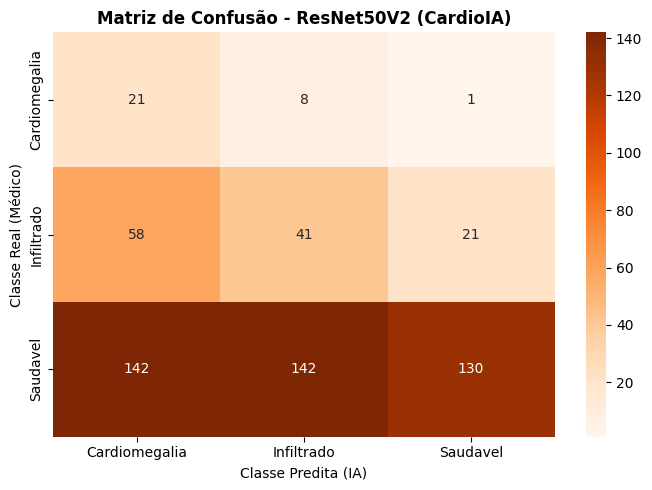


--- RELATÓRIO DE MÉTRICAS (RESNET50V2) ---
               precision    recall  f1-score   support

Cardiomegalia       0.10      0.70      0.17        30
   Infiltrado       0.21      0.34      0.26       120
     Saudavel       0.86      0.31      0.46       414

     accuracy                           0.34       564
    macro avg       0.39      0.45      0.30       564
 weighted avg       0.68      0.34      0.40       564



In [ ]:
print("🔮 Computando predições para o conjunto de teste oculto...")
predictions_cardioia = model_cardioia.predict(test_ds, verbose=1)
y_pred_cardioia = np.argmax(predictions_cardioia, axis=1)

# Matriz de Confusão
cm_cardioia = confusion_matrix(y_true_indices, y_pred_cardioia)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_cardioia, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão Definitiva - CardioIA (DenseNet121)', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n📋 --- RELATÓRIO DE MÉTRICAS DETALHADO (DENSENET121) ---")
print(classification_report(y_true_indices, y_pred_cardioia, target_names=class_names))

Exportação do Melhor Modelo para a Interface Flask

In [ ]:
caminho_salvamento = r"C:\Users\Fran\app_mobile_fase4\seu_modelo.h5"

# Salva a melhor rede convolucional
model_resnet.save(caminho_salvamento)

print(f"Sucesso! O modelo ResNet50V2 foi exportado para o App Mobile em:\n{caminho_salvamento}")

Sucesso! O modelo ResNet50V2 foi exportado para o App Mobile em:
C:\Users\Fran\app_mobile_fase4\seu_modelo.h5
